In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import distance
import os

In [2]:
PATH = os.path.expanduser('~') + '/Dropbox/suvranil/cellmem'

In [3]:
df = pd.read_csv(PATH + '/data/MemSeqData/HighVariable5000CountMatrix_batch_1.csv')
df.set_index('Unnamed: 0', inplace = True)
df

,AAACGCTTCCGGACGT-1,AAAGGGCTCAGACAAA-1,AAAGTCCGTCCTCAGG-1,AAAGTGAGTGAGTGAC-1,AAAGTGAGTGTGCTTA-1,AAAGTGATCAAACGAA-1,AAATGGATCAAGTGTC-1,AACAAAGAGGCCCAAA-1,AACAACCCACAGTCGC-1,AACACACGTACCGGCT-1,...,TTTGGAGCACCTGATA-4,TTTGGAGTCCTGGGAC-4,TTTGGAGTCTTAGTTC-4,TTTGGTTAGACGAGCT-4,TTTGGTTAGACTGAGC-4,TTTGGTTAGATTGGGC-4,TTTGGTTGTTGTATGC-4,TTTGTTGAGATGGCAC-4,TTTGTTGGTGTGATGG-4,TTTGTTGTCTGGTGCG-4
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
PRR9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
DKK1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
CCL5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
OASL,0.000007,0.000013,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000031,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
PTGS2,0.000007,0.000000,0.000110,0.000000,0.000000,0.000000,0.000000,0.000000,0.000009,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ITGA5,0.000022,0.000040,0.000022,0.000059,0.000041,0.000011,0.000008,0.000000,0.000018,0.000110,...,0.000000,0.000131,0.000021,0.000000,0.000063,0.000000,0.000000,0.000000,0.0,0.0
TFAP2C,0.000065,0.000067,0.000110,0.000010,0.000082,0.000000,0.000000,0.000107,0.000000,0.000016,...,0.000000,0.000230,0.000000,0.000000,0.000031,0.000000,0.000029,0.000000,0.0,0.0
SETD1B,0.000007,0.000027,0.000000,0.000000,0.000000,0.000000,0.000000,0.000013,0.000009,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000017,0.0,0.0


In [4]:
sod_arr = np.loadtxt(PATH + "/data/MemSeqData/sod_order_batch_1.txt")
order = sod_arr.argsort()[:: -1]

## Jensen Shannon divergence

In [5]:
distance_box = np.ones(5000)
for i in range (5000):
    test = df.loc[df.index[order][i]].to_numpy()
    cluster_1 = np.argsort(test)[::-1][: 1000]
    base = df.loc[df.index[order][1]].to_numpy()
    base_cluster = base[cluster_1]
    p = np.histogram(base, bins = 400, range=(base.min(), base.max()), density=True)[0]
    p1 = np.histogram(base_cluster, bins = 400, range=(base.min(), base.max()), density=True)[0]
    distance_box[i] = distance.jensenshannon(p, p1)
x = np.linspace(1, 5000, 5000)

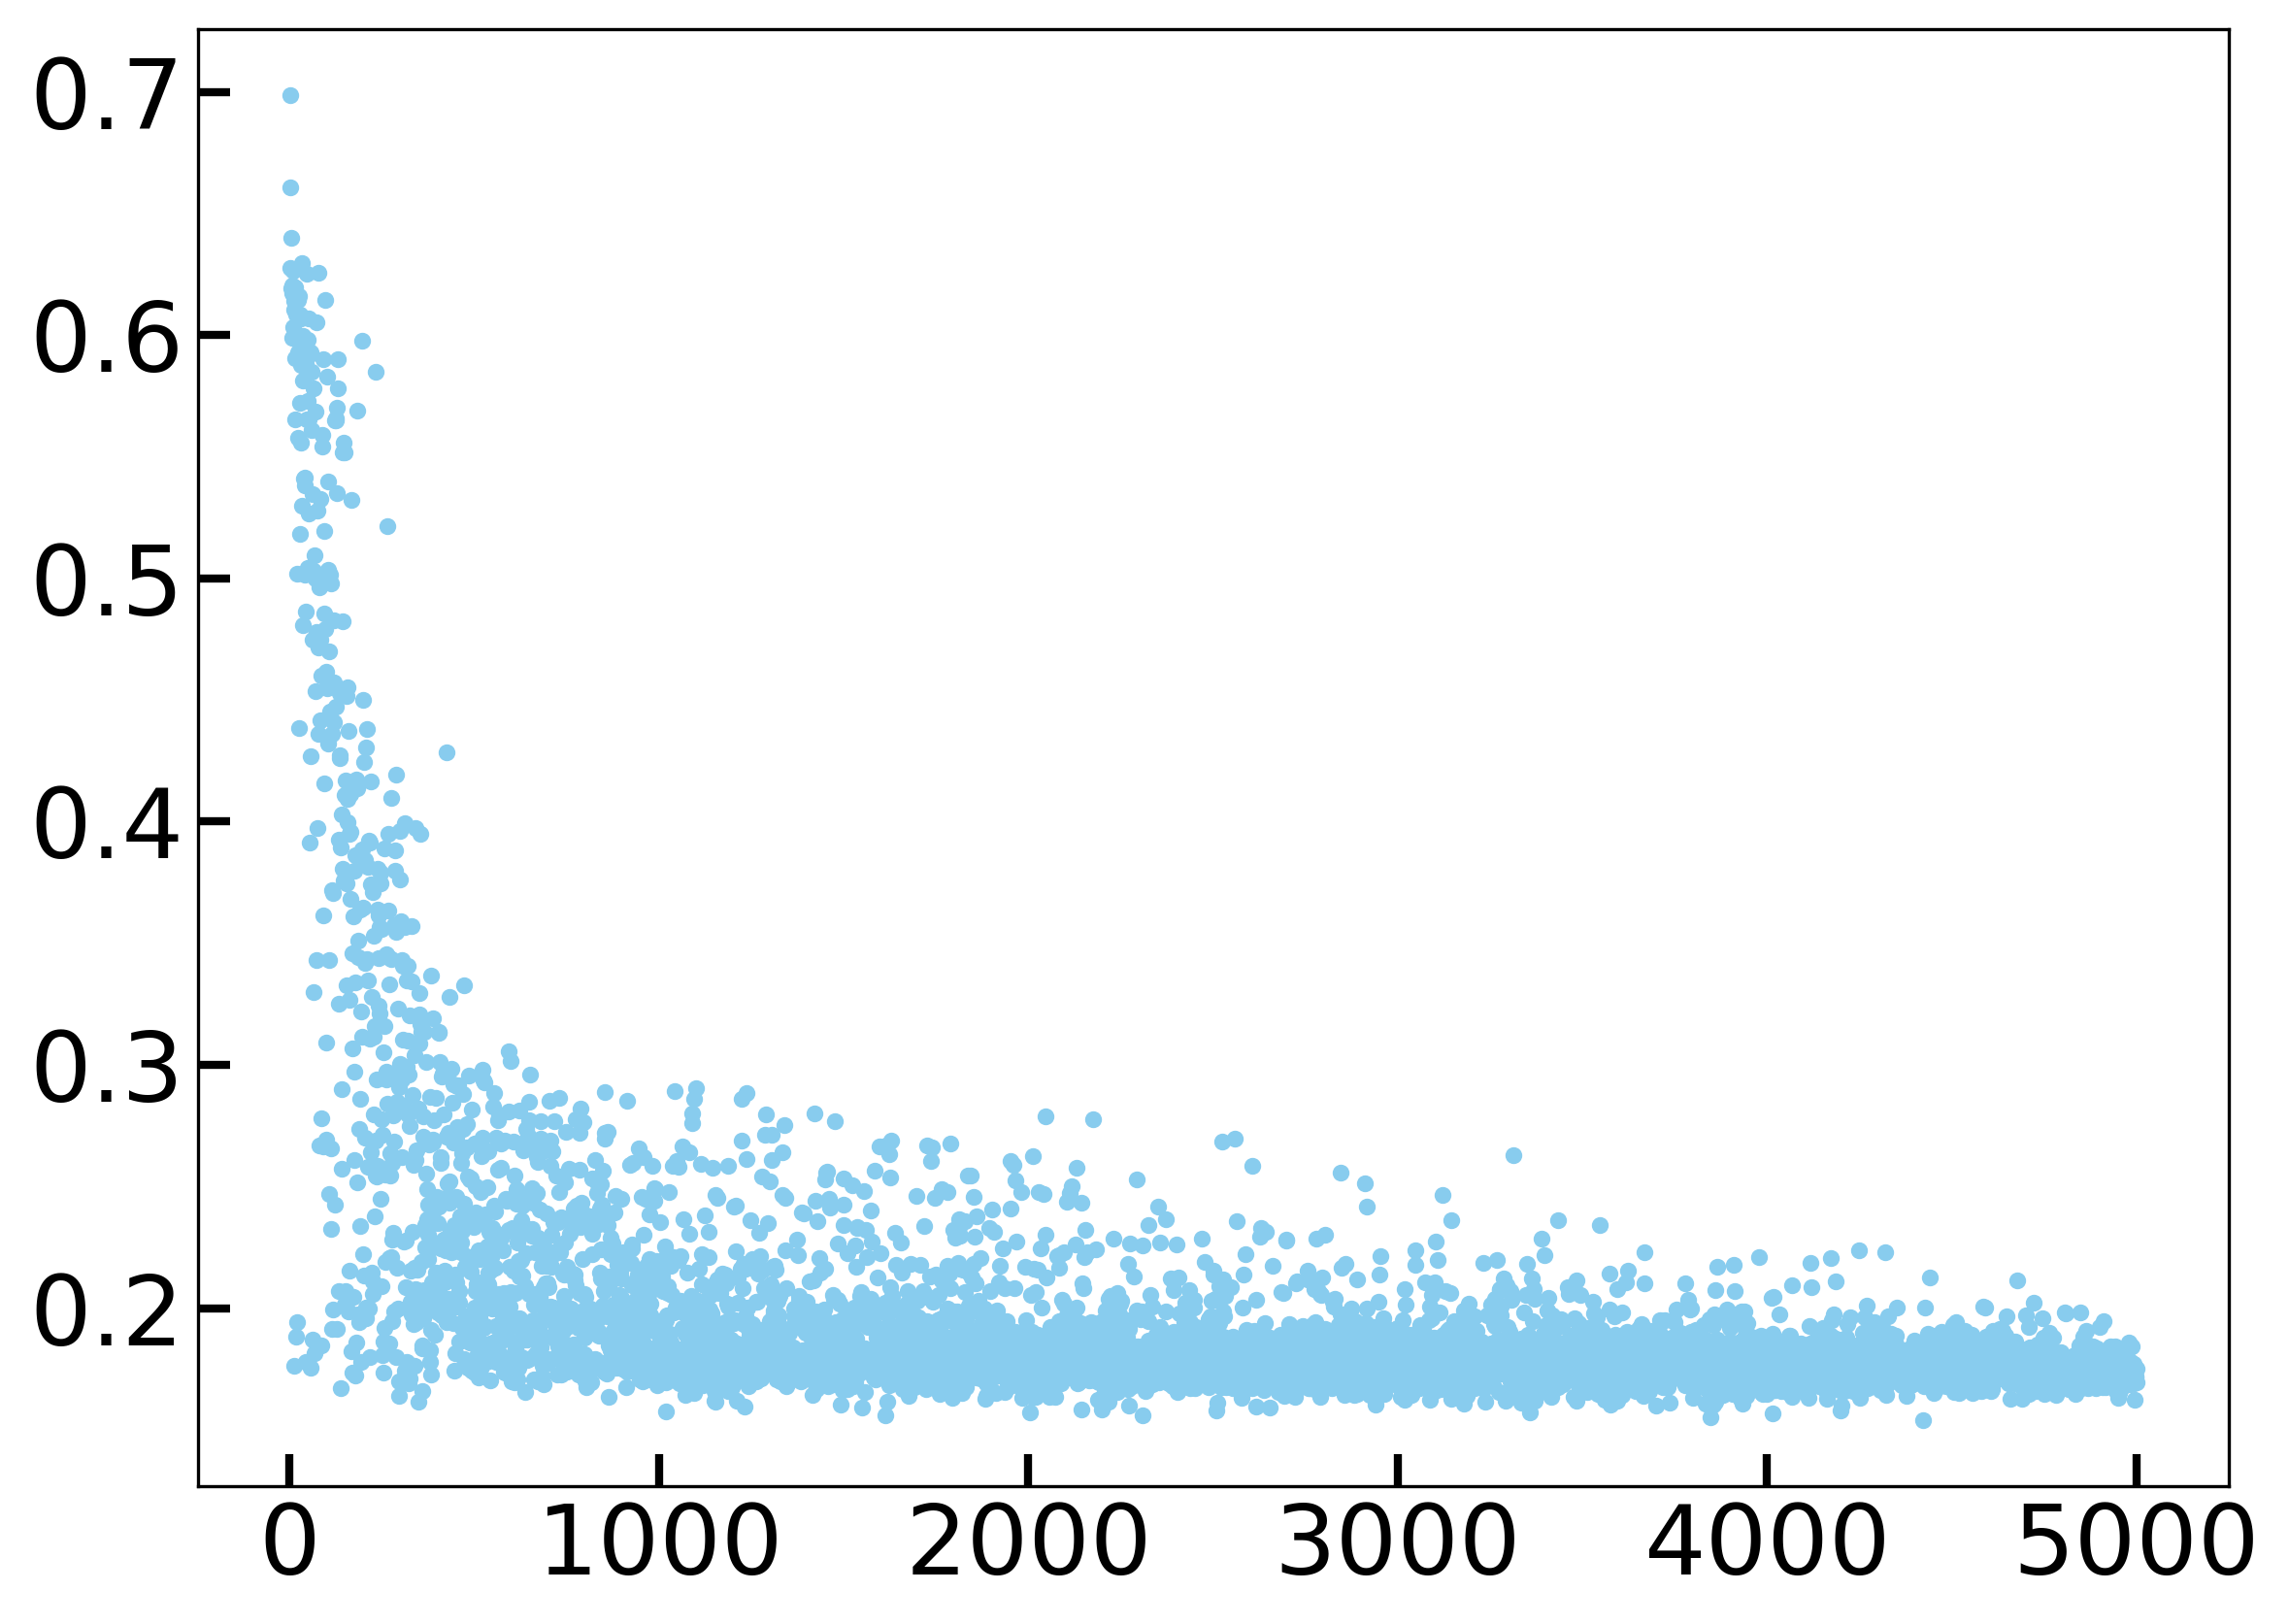

In [6]:
xData = np.linspace(1, len(sod_arr), len(sod_arr))
f = plt.figure(figsize=(9, 6.5), dpi = 300)
ax = f.add_subplot()


# ax.plot([0, 5000], [0, 0], '--')
ax.scatter(x, distance_box, s = 10, color = '#88ccee', 
           edgecolors = '#88ccee' , linewidth = 1.0)

ax.tick_params(axis='y',labelsize=24, width = 3)
ax.tick_params(axis='x',labelsize=24, width = 3)
ax.tick_params(which="minor", length = 0)
ax.tick_params(which="major", direction='in', length = 8, 
               width = 2)
#plt.savefig(PATH + "/PaperFig/Fig4JSDistance.pdf", transparent=True, dpi = 300)